# Pilot Method Selection — Visual Encoding of Importance in Paintings

**Thesis:** *Visual Encoding of Importance in Paintings: A Computational Analysis of Isolation, Elevation, and Salience*
Micah Philippe John — BSc AI, University of Amsterdam — supervisor: Nanne van Noord

This notebook runs the **Renaissance pilot**. Importance ground truth comes from
hand-drawn bounding boxes (VIA export), **not** from a CSV column. The pipeline is:

1. **Setup** — installs, imports, paths
2. **Feature extraction techniques** — isolation, elevation, salience, composites
3. **Importance ground truth** — load hand-drawn important-figure boxes from the VIA JSON
4. **YOLO + IoU validation gate** — for every painting, check whether YOLO detected the
   important figure; calibrate the IoU threshold, then **drop paintings that fail the gate**
5. **Batch run** — SAM3 + DIS + feature extraction, on the paintings that passed the gate
6. **Annotation** — match each hand-drawn box to a detected figure (`is_important`)
7. **Important-figure counts** — distribution across the passing paintings
8. **Technique ranking** — standard ranking metrics (Precision@1, Recall@3, MRR, Hit@3)
9. **Conclusion** — techniques locked in for the full run

The CSV is used only for painting titles. All importance information comes from the VIA boxes.

# 1. Setup

In [17]:
# Install the libraries used in this notebook.
# Anything already installed is silently skipped, so this is safe to re-run.
%pip install numpy pandas scipy opencv-python pillow matplotlib tqdm scikit-image scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import re
import gc
import json
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from tqdm import tqdm
from pathlib import Path
from functools import reduce
from PIL import Image

# Renaissance paintings can be very large. Pillow refuses to open these by default,
# so the limit is removed (we control input ourselves, no DoS risk).
Image.MAX_IMAGE_PIXELS = None


## 1.1 Paths

`BASE_DIR` is the pilot images folder. The two new paths are the VIA export (hand-drawn
important-figure boxes) and the YOLO 0.25 person-only detections.

In [19]:
# Paths
BASE_DIR  = Path.home() / "Thesis" / "Images" / "Pilot Images"
DIS_DIR   = BASE_DIR / "dis"

# Importance ground truth: hand-drawn boxes exported from VIA.
VIA_JSON_PATH = BASE_DIR / "Important fig json" / "via_export_json.json"

# YOLOv7 person-only detections at confidence 0.25 (--save-txt --save-conf format).
YOLO_DIR        = BASE_DIR / "YOLO persons_only_025"
YOLO_LABELS_DIR = YOLO_DIR / "labels"

# Plain painting images and SAM3 masks (used later, in the batch run).
PLAIN_IMAGES_DIR = BASE_DIR / "Plain images"
SAM3_ROOT        = BASE_DIR / "outputs yolo 0.25" / "sam3"

for label, p in [
    ("BASE_DIR",         BASE_DIR),
    ("DIS_DIR",          DIS_DIR),
    ("VIA_JSON_PATH",    VIA_JSON_PATH),
    ("YOLO_LABELS_DIR",  YOLO_LABELS_DIR),
    ("PLAIN_IMAGES_DIR", PLAIN_IMAGES_DIR),
    ("SAM3_ROOT",        SAM3_ROOT),
]:
    print(f"{label:18} {p}   exists: {p.exists()}")

BASE_DIR           /home/micah/Thesis/Images/Pilot Images   exists: True
DIS_DIR            /home/micah/Thesis/Images/Pilot Images/dis   exists: True
VIA_JSON_PATH      /home/micah/Thesis/Images/Pilot Images/Important fig json/via_export_json.json   exists: True
YOLO_LABELS_DIR    /home/micah/Thesis/Images/Pilot Images/YOLO persons_only_025/labels   exists: True
PLAIN_IMAGES_DIR   /home/micah/Thesis/Images/Pilot Images/Plain images   exists: True
SAM3_ROOT          /home/micah/Thesis/Images/Pilot Images/outputs yolo 0.25/sam3   exists: True


In [20]:
# Output folder for everything this notebook produces.
PILOT_OUTPUT_DIR  = BASE_DIR / "pilot_method_selection_outputs"
PILOT_FEATURE_DIR = PILOT_OUTPUT_DIR / "features_per_painting"
PILOT_PREVIEW_DIR = PILOT_OUTPUT_DIR / "figure_id_previews"
PILOT_SCORE_DIR   = PILOT_OUTPUT_DIR / "scores"

for d in (PILOT_FEATURE_DIR, PILOT_PREVIEW_DIR, PILOT_SCORE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Pilot output folder:", PILOT_OUTPUT_DIR)

Pilot output folder: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs


# 2. Feature Extraction Techniques

Three feature families, one code cell each, plus a composite-builder. Pure functions —
nothing here touches the dataset; that starts in Section 3.

## 2.1 Isolation

In [21]:
"""
Isolation features.

Idea: a figure is "isolated" if it sits far from the other figures in the painting.
A few different definitions are tested below so I can pick the most useful one.

Candidate measures:
1. iso_nearest_centroid_norm   - distance to the closest other figure
2. iso_average_centroid_norm   - mean distance to all other figures
3. iso_local_density_r{N}      - how many figures fall inside a radius of N% of the diagonal
4. iso_nearest_boundary_norm   - shortest mask-to-mask distance (slow, optional)

References:
- Binary mask centroid via np.where:
  https://stackoverflow.com/questions/38933566/quickly-calculating-centroid-of-binary-numpy-array
- OpenCV image-moment centroids:
  https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html
- scipy.spatial.cKDTree (used for nearest-neighbour and radius queries):
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html
- OpenCV distance transform (background reading for boundary distance):
  https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html
"""

def image_diagonal(image_width, image_height):
    return np.sqrt(image_width ** 2 + image_height ** 2)


def bbox_centroid(bbox):
    """Centre of a [x1, y1, x2, y2] box. Used as a fallback when no mask is available."""
    x1, y1, x2, y2 = bbox
    return float((x1 + x2) / 2), float((y1 + y2) / 2)


def mask_centroid(mask):
    """Centre of mass of a binary mask."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return np.nan, np.nan
    return float(xs.mean()), float(ys.mean())


def get_figure_centroid(figure):
    """Prefer the SAM3 mask centroid; fall back to the YOLO bbox centroid."""
    mask = figure.get("mask", None)
    bbox = figure.get("bbox", None)

    if mask is not None and np.any(mask > 0):
        return mask_centroid(mask)
    if bbox is not None:
        return bbox_centroid(bbox)
    return np.nan, np.nan


def min_mask_boundary_distance(mask_a, mask_b, image_width, image_height, stride=5):
    """
    Approximate shortest distance between two masks.

    Centroid distance is misleading for large figures: two big masks can have
    far-apart centroids while still overlapping. Boundary distance fixes that.

    `stride` subsamples the masks for speed - 5 is good enough for pilot work.
    """
    if mask_a is None or mask_b is None:
        return np.nan

    coords_a = np.column_stack(np.where(mask_a > 0))[::stride]
    coords_b = np.column_stack(np.where(mask_b > 0))[::stride]
    if len(coords_a) == 0 or len(coords_b) == 0:
        return np.nan

    distances, _ = cKDTree(coords_b).query(coords_a, k=1)
    return float(np.min(distances) / image_diagonal(image_width, image_height))


def compute_isolation_features(
    painting_id,
    figures,
    image_width,
    image_height,
    local_density_radii=(0.10, 0.15, 0.20),
    compute_boundary_distance=False,
):
    """Returns one row per figure with all the isolation candidates."""

    rows = []
    centers = []
    masks = []

    for fig in figures:
        cx, cy = get_figure_centroid(fig)
        centers.append([cx, cy])
        masks.append(fig.get("mask", None))

        rows.append({
            "painting_id": painting_id,
            "figure_id": fig["figure_id"],
            "centroid_x": cx,
            "centroid_y": cy,
            "centroid_x_norm": cx / image_width if not np.isnan(cx) else np.nan,
            "centroid_y_norm": cy / image_height if not np.isnan(cy) else np.nan,
        })

    df = pd.DataFrame(rows)
    centers = np.array(centers, dtype=float)
    diag = image_diagonal(image_width, image_height)

    # Initialise output columns with NaN; valid figures will be filled below.
    df["iso_nearest_centroid_norm"] = np.nan
    df["iso_average_centroid_norm"] = np.nan
    for radius_frac in local_density_radii:
        df[f"iso_local_density_r{int(radius_frac * 100):02d}"] = np.nan
    df["iso_nearest_boundary_norm"] = np.nan

    valid = ~np.isnan(centers).any(axis=1)
    if valid.sum() <= 1:
        # Need at least two figures to talk about isolation.
        return df

    valid_indices = np.where(valid)[0]
    valid_centers = centers[valid]

    # Pairwise centroid distances. Diagonal is NaN so a figure isn't its own neighbour.
    D = cdist(valid_centers, valid_centers)
    np.fill_diagonal(D, np.nan)

    df.loc[valid_indices, "iso_nearest_centroid_norm"] = np.nanmin(D, axis=1) / diag
    df.loc[valid_indices, "iso_average_centroid_norm"] = np.nanmean(D, axis=1) / diag

    # Local density: how many other figures fall within a radius?
    tree = cKDTree(valid_centers)
    for radius_frac in local_density_radii:
        radius_px = radius_frac * diag
        neighbors = tree.query_ball_point(valid_centers, r=radius_px)
        # Subtract 1 because the figure itself is included in its own ball.
        density = np.array([len(n) - 1 for n in neighbors], dtype=float)
        df.loc[valid_indices, f"iso_local_density_r{int(radius_frac * 100):02d}"] = density

    # Optional, slow: pairwise mask-boundary distance.
    if compute_boundary_distance:
        for i in range(len(figures)):
            distances = []
            for j in range(len(figures)):
                if i == j:
                    continue
                d = min_mask_boundary_distance(masks[i], masks[j], image_width, image_height, stride=5)
                if not np.isnan(d):
                    distances.append(d)
            if distances:
                df.loc[i, "iso_nearest_boundary_norm"] = np.min(distances)

    # Per-painting ranks. Higher distance / lower density = more isolated.
    df["rank_iso_nearest_centroid"] = df["iso_nearest_centroid_norm"].rank(ascending=False, method="min")
    df["rank_iso_average_centroid"] = df["iso_average_centroid_norm"].rank(ascending=False, method="min")
    df["rank_iso_nearest_boundary"] = df["iso_nearest_boundary_norm"].rank(ascending=False, method="min")
    for radius_frac in local_density_radii:
        col = f"iso_local_density_r{int(radius_frac * 100):02d}"
        df[f"rank_{col}"] = df[col].rank(ascending=True, method="min")

    return df


## 2.2 Elevation

In [22]:
"""
Elevation features.

Idea: in a Renaissance composition, the protagonist tends to be placed higher
in the frame. So a figure with a smaller y-coordinate is potentially more important.

Important coordinate convention:
- Image y-axis points downward (y=0 is the top edge).
- Therefore: elevation = 1 - y / image_height
  -> top of the image = 1.0, bottom = 0.0

Candidate measures:
1. elev_mask_centroid   - elevation of the mask centroid
2. elev_bbox_centroid   - elevation of the bbox centroid
3. elev_mask_top        - elevation of the mask's topmost pixel
4. elev_bbox_top        - elevation of the bbox's top edge
5. elev_mask_bottom     - elevation of the mask's bottom (where the figure stands)
6. elev_bbox_bottom     - elevation of the bbox's bottom edge
7. elev_upper_body_proxy - mean y of the top 35% of the mask (skips long robes / drapery)

References:
- OpenCV moments tutorial:
  https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html
- np.where for binary mask coordinates:
  https://stackoverflow.com/questions/38933566/quickly-calculating-centroid-of-binary-numpy-array
"""


def safe_elevation(y_value, image_height):
    """Convert image y to elevation in [0, 1]. NaN-safe."""
    if y_value is None or np.isnan(y_value):
        return np.nan
    return float(1 - (y_value / image_height))


def mask_bounds(mask):
    """Tight bounding box around a binary mask: (x_min, y_min, x_max, y_max)."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return np.nan, np.nan, np.nan, np.nan
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())


def upper_body_proxy_y(mask, upper_fraction=0.35):
    """
    Mean y of the upper portion of the mask. Acts as a proxy for the head/upper-body region.

    Why this exists: a full-mask centroid gets pulled downward by long robes, capes,
    horses, podiums etc. The bare mask top is too noisy (hats, halos, raised hands).
    Averaging over the top `upper_fraction` of the mask is a good middle ground.
    """
    if mask is None or not np.any(mask > 0):
        return np.nan

    ys, _ = np.where(mask > 0)
    y_top, y_bottom = ys.min(), ys.max()
    cutoff = y_top + upper_fraction * (y_bottom - y_top)
    upper_ys = ys[ys <= cutoff]

    if len(upper_ys) == 0:
        return np.nan
    return float(upper_ys.mean())


def compute_elevation_features(painting_id, figures, image_width, image_height):
    """Returns one row per figure with all the elevation candidates."""

    rows = []

    for fig in figures:
        figure_id = fig["figure_id"]
        bbox = fig.get("bbox", None)
        mask = fig.get("mask", None)

        bbox_cx, bbox_cy = np.nan, np.nan
        mask_cx, mask_cy = np.nan, np.nan
        bbox_top_y, bbox_bottom_y = np.nan, np.nan
        mask_top_y, mask_bottom_y = np.nan, np.nan
        upper_proxy_y = np.nan

        if bbox is not None:
            x1, y1, x2, y2 = bbox
            bbox_cx, bbox_cy = bbox_centroid(bbox)
            bbox_top_y, bbox_bottom_y = y1, y2

        if mask is not None and np.any(mask > 0):
            mask_cx, mask_cy = mask_centroid(mask)
            _, y1_m, _, y2_m = mask_bounds(mask)
            mask_top_y, mask_bottom_y = y1_m, y2_m
            upper_proxy_y = upper_body_proxy_y(mask, upper_fraction=0.35)

        rows.append({
            "painting_id": painting_id,
            "figure_id": figure_id,

            # Raw y-values, kept for debugging.
            "bbox_centroid_y":    bbox_cy,
            "mask_centroid_y":    mask_cy,
            "bbox_top_y":         bbox_top_y,
            "mask_top_y":         mask_top_y,
            "bbox_bottom_y":      bbox_bottom_y,
            "mask_bottom_y":      mask_bottom_y,
            "upper_body_proxy_y": upper_proxy_y,

            # Normalised y-values.
            "bbox_centroid_y_norm":    bbox_cy / image_height if not np.isnan(bbox_cy) else np.nan,
            "mask_centroid_y_norm":    mask_cy / image_height if not np.isnan(mask_cy) else np.nan,
            "bbox_top_y_norm":         bbox_top_y / image_height if not np.isnan(bbox_top_y) else np.nan,
            "mask_top_y_norm":         mask_top_y / image_height if not np.isnan(mask_top_y) else np.nan,
            "bbox_bottom_y_norm":      bbox_bottom_y / image_height if not np.isnan(bbox_bottom_y) else np.nan,
            "mask_bottom_y_norm":      mask_bottom_y / image_height if not np.isnan(mask_bottom_y) else np.nan,
            "upper_body_proxy_y_norm": upper_proxy_y / image_height if not np.isnan(upper_proxy_y) else np.nan,

            # Elevation scores: higher = more elevated in the frame.
            "elev_bbox_centroid":    safe_elevation(bbox_cy, image_height),
            "elev_mask_centroid":    safe_elevation(mask_cy, image_height),
            "elev_bbox_top":         safe_elevation(bbox_top_y, image_height),
            "elev_mask_top":         safe_elevation(mask_top_y, image_height),
            "elev_bbox_bottom":      safe_elevation(bbox_bottom_y, image_height),
            "elev_mask_bottom":      safe_elevation(mask_bottom_y, image_height),
            "elev_upper_body_proxy": safe_elevation(upper_proxy_y, image_height),
        })

    df = pd.DataFrame(rows)

    # Per-painting ranks. Higher elevation = better rank.
    elevation_cols = [
        "elev_bbox_centroid", "elev_mask_centroid",
        "elev_bbox_top",      "elev_mask_top",
        "elev_bbox_bottom",   "elev_mask_bottom",
        "elev_upper_body_proxy",
    ]
    for col in elevation_cols:
        df[f"rank_{col}"] = df[col].rank(ascending=False, method="min")

    return df


## 2.3 Salience

In [23]:
"""
Saliency features.

Idea: a figure that occupies a salient region of the painting (according to a
salient-object detector) is more likely to be important. The saliency map is
produced by DIS, run separately and stored as grayscale PNGs.

Candidate measures:
1.  sal_mean                    - average saliency inside the mask
2.  sal_median                  - median saliency inside the mask
3.  sal_sum                     - total saliency inside the mask
4.  sal_share                   - fraction of the painting's total saliency
5.  sal_max                     - peak saliency inside the mask
6.  sal_p90                     - 90th percentile (a robust max)
7.  sal_high_coverage_{50,75,90} - fraction of the mask above a threshold
8.  sal_contrast_to_image_mean  - figure mean / image mean
9.  sal_contrast_to_surrounding - figure mean / mean in a 40px halo around the figure

References:
- DIS (Highly Accurate Dichotomous Image Segmentation):
  https://github.com/xuebinqin/DIS
  https://xuebinqin.github.io/dis/index.html
- OpenCV image I/O and resize:
  https://docs.opencv.org/4.x/
"""


def normalize_to_01(arr):
    """Min-max normalise an array to [0, 1]. Returns zeros if the array is constant."""
    arr = arr.astype(np.float32)
    min_val, max_val = float(np.min(arr)), float(np.max(arr))
    if max_val == min_val:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - min_val) / (max_val - min_val)


def load_saliency_map(path, target_shape=None):
    """
    Load a DIS output as a grayscale map and normalise to [0, 1].
    `target_shape=(H, W)` resizes to match the painting.
    """
    sal = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if sal is None:
        raise ValueError(f"Could not load saliency map: {path}")
    if target_shape is not None:
        H, W = target_shape
        sal = cv2.resize(sal, (W, H), interpolation=cv2.INTER_LINEAR)
    return normalize_to_01(sal)


def bbox_region_mask(bbox, image_width, image_height):
    """Build a rectangular boolean mask from a bbox. Used only as a fallback when no SAM3 mask is available."""
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, min(x1, image_width - 1))
    x2 = max(0, min(x2, image_width))
    y1 = max(0, min(y1, image_height - 1))
    y2 = max(0, min(y2, image_height))

    region = np.zeros((image_height, image_width), dtype=bool)
    region[y1:y2, x1:x2] = True
    return region


def dilated_surrounding_region(mask, dilation_px=40):
    """
    Build a "halo" around the figure: the dilated mask minus the mask itself.

    Used to compare saliency inside the figure vs. saliency immediately around it.
    A figure that's much more salient than its surroundings stands out locally.
    """
    mask_uint8 = mask.astype(np.uint8)
    kernel = np.ones((dilation_px, dilation_px), np.uint8)
    dilated = cv2.dilate(mask_uint8, kernel, iterations=1).astype(bool)
    return np.logical_and(dilated, ~mask.astype(bool))


def compute_saliency_features(
    painting_id,
    figures,
    saliency_map,
    image_width,
    image_height,
    high_thresholds=(0.50, 0.75, 0.90),
    surrounding_dilation_px=40,
):
    """Returns one row per figure with all the saliency candidates."""

    rows = []
    image_mean = float(np.mean(saliency_map))
    image_sum  = float(np.sum(saliency_map))

    for fig in figures:
        figure_id = fig["figure_id"]
        mask = fig.get("mask", None)
        bbox = fig.get("bbox", None)

        # Prefer the SAM3 mask, fall back to the YOLO box, otherwise emit NaNs.
        if mask is not None and np.any(mask > 0):
            figure_region = mask.astype(bool)
            region_source = "mask"
        elif bbox is not None:
            figure_region = bbox_region_mask(bbox, image_width, image_height)
            region_source = "bbox"
        else:
            figure_region = None
            region_source = "none"

        if figure_region is None or not np.any(figure_region):
            row = {
                "painting_id": painting_id,
                "figure_id": figure_id,
                "sal_region_source": region_source,
                "sal_mean": np.nan, "sal_median": np.nan, "sal_sum": np.nan, "sal_share": np.nan,
                "sal_max": np.nan, "sal_p90": np.nan,
                "sal_contrast_to_image_mean": np.nan,
                "sal_surrounding_mean": np.nan, "sal_contrast_to_surrounding": np.nan,
            }
            for t in high_thresholds:
                row[f"sal_high_coverage_{int(t * 100)}"] = np.nan
            rows.append(row)
            continue

        values = saliency_map[figure_region]

        sal_mean   = float(np.mean(values))
        sal_median = float(np.median(values))
        sal_sum    = float(np.sum(values))
        sal_share  = sal_sum / image_sum if image_sum > 0 else np.nan
        sal_max    = float(np.max(values))
        sal_p90    = float(np.percentile(values, 90))
        sal_contrast_to_image_mean = sal_mean / image_mean if image_mean > 0 else np.nan

        # Local contrast: figure vs. its halo. Only meaningful when we have a real mask.
        if mask is not None and np.any(mask > 0):
            surrounding = dilated_surrounding_region(mask.astype(bool), dilation_px=surrounding_dilation_px)
            if np.any(surrounding):
                sal_surrounding_mean = float(np.mean(saliency_map[surrounding]))
                sal_contrast_to_surrounding = (
                    sal_mean / sal_surrounding_mean if sal_surrounding_mean > 0 else np.nan
                )
            else:
                sal_surrounding_mean = np.nan
                sal_contrast_to_surrounding = np.nan
        else:
            sal_surrounding_mean = np.nan
            sal_contrast_to_surrounding = np.nan

        row = {
            "painting_id": painting_id,
            "figure_id": figure_id,
            "sal_region_source": region_source,
            "sal_mean": sal_mean, "sal_median": sal_median, "sal_sum": sal_sum, "sal_share": sal_share,
            "sal_max": sal_max, "sal_p90": sal_p90,
            "sal_contrast_to_image_mean": sal_contrast_to_image_mean,
            "sal_surrounding_mean": sal_surrounding_mean,
            "sal_contrast_to_surrounding": sal_contrast_to_surrounding,
        }

        # Coverage above each threshold: "how much of the figure is highly salient?"
        for t in high_thresholds:
            row[f"sal_high_coverage_{int(t * 100)}"] = float(np.mean(values >= t))

        rows.append(row)

    df = pd.DataFrame(rows)

    # Per-painting ranks. Higher saliency = better rank.
    saliency_cols = [
        "sal_mean", "sal_median", "sal_sum", "sal_share",
        "sal_max", "sal_p90",
        "sal_contrast_to_image_mean", "sal_contrast_to_surrounding",
    ]
    for t in high_thresholds:
        saliency_cols.append(f"sal_high_coverage_{int(t * 100)}")

    for col in saliency_cols:
        if col in df.columns:
            df[f"rank_{col}"] = df[col].rank(ascending=False, method="min")

    return df


## 2.4 Composite scores

In [24]:
"""
Composite features.

Idea: even if no single isolation/elevation/saliency measure works perfectly,
maybe a weighted blend of the best one from each family does.

The blend is built in two steps:
1. Min-max normalise each feature WITHIN each painting (to [0, 1]).
   This is essential - paintings differ in scale, figure count, and saliency intensity,
   so the only fair comparison is between figures inside the same painting.
2. Take a weighted sum (or min, or max) of the three normalised scores.
"""


def minmax_normalize_within_painting(
    df,
    feature_col,
    painting_col="painting_id",
    higher_is_better=True,
):
    """
    Normalise `feature_col` to [0, 1] separately per painting.
    If `higher_is_better=False`, the result is flipped so that higher = better.
    """
    df = df.copy()
    if feature_col not in df.columns:
        raise ValueError(f"Feature column not found: {feature_col}")

    output_col = f"norm_{feature_col}"
    df[output_col] = np.nan

    for painting_id, group in df.groupby(painting_col):
        values = group[feature_col].astype(float)
        valid = values.notna()
        if valid.sum() == 0:
            continue

        v = values[valid]
        min_v, max_v = v.min(), v.max()

        if max_v == min_v:
            # All figures tied - assign 0.5 so they don't all hit the extreme.
            normalized = pd.Series(np.full(len(v), 0.5), index=v.index)
        else:
            normalized = (v - min_v) / (max_v - min_v)

        if not higher_is_better:
            normalized = 1 - normalized

        df.loc[normalized.index, output_col] = normalized

    return df


def add_composite_scores(
    df,
    isolation_feature,
    elevation_feature,
    saliency_feature,
    isolation_higher_is_better=True,
    elevation_higher_is_better=True,
    saliency_higher_is_better=True,
):
    """
    Add several composite-score columns to `df`.

    Each composite is a different opinion about which cue should dominate.
    The pilot tests them all and the strongest one gets locked in for the full run.
    """
    df = df.copy()

    required_cols = [isolation_feature, elevation_feature, saliency_feature]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = minmax_normalize_within_painting(df, isolation_feature, higher_is_better=isolation_higher_is_better)
    df = minmax_normalize_within_painting(df, elevation_feature, higher_is_better=elevation_higher_is_better)
    df = minmax_normalize_within_painting(df, saliency_feature,  higher_is_better=saliency_higher_is_better)

    iso  = f"norm_{isolation_feature}"
    elev = f"norm_{elevation_feature}"
    sal  = f"norm_{saliency_feature}"

    # Equal weighting - the simplest baseline.
    df["combo_equal_iso_elev_sal"] = df[[iso, elev, sal]].mean(axis=1)

    # Weighted blends. Each one tests a different theoretical claim.
    df["combo_saliency_heavy"]  = 0.50 * df[sal]  + 0.25 * df[iso]  + 0.25 * df[elev]
    df["combo_spatial_heavy"]   = 0.40 * df[iso]  + 0.40 * df[elev] + 0.20 * df[sal]
    df["combo_isolation_heavy"] = 0.50 * df[iso]  + 0.25 * df[sal]  + 0.25 * df[elev]
    df["combo_elevation_heavy"] = 0.50 * df[elev] + 0.25 * df[sal]  + 0.25 * df[iso]

    # Pairs - in case one of the three is just adding noise.
    df["combo_iso_sal"]  = 0.50 * df[iso]  + 0.50 * df[sal]
    df["combo_elev_sal"] = 0.50 * df[elev] + 0.50 * df[sal]
    df["combo_iso_elev"] = 0.50 * df[iso]  + 0.50 * df[elev]

    # Conservative: the figure has to do reasonably well on all three.
    df["combo_minimum_score"] = df[[iso, elev, sal]].min(axis=1)

    # Lenient: a single very strong cue is enough.
    df["combo_maximum_score"] = df[[iso, elev, sal]].max(axis=1)

    return df


# 3. Importance Ground Truth (VIA boxes)

Importance is defined by hand-drawn bounding boxes exported from the VIA annotation
tool, **not** by a CSV column. For each painting the VIA export gives an ordered list
of important-figure boxes:

- the **first** box is the *main* important figure
- any **subsequent** boxes are *supporting* important figures

This is the single source of importance ground truth for the whole notebook.

In [25]:
# Load the VIA export and turn each painting's regions into ordered (x1,y1,x2,y2) boxes.
with open(VIA_JSON_PATH, "r") as f:
    via_raw = json.load(f)

via_important_boxes = {}   # painting_id -> [(x1,y1,x2,y2), ...]   first box = main figure
for entry in via_raw.values():
    pid = str(entry["filename"]).replace(".jpg", "")
    boxes = []
    for region in entry["regions"]:
        a = region["shape_attributes"]
        if a.get("name") != "rect":
            continue
        x1, y1 = float(a["x"]), float(a["y"])
        x2, y2 = x1 + float(a["width"]), y1 + float(a["height"])
        boxes.append((x1, y1, x2, y2))
    via_important_boxes[pid] = boxes

n_boxes = sum(len(b) for b in via_important_boxes.values())
print(f"Loaded {n_boxes} hand-drawn important-figure boxes "
      f"across {len(via_important_boxes)} paintings.")

# Quick overview: how many important figures has each painting been given?
via_overview = pd.DataFrame([
    {"painting_id": pid, "n_important_boxes": len(boxes)}
    for pid, boxes in sorted(via_important_boxes.items(), key=lambda kv: int(kv[0]))
])
display(via_overview)

Loaded 49 hand-drawn important-figure boxes across 25 paintings.


,painting_id,n_important_boxes
0,1,3
1,2,3
2,3,2
3,4,2
4,5,2
5,6,2
6,7,4
7,8,2
8,9,2
9,10,2


# 4. YOLO Detection and the IoU Validation Gate

This is the gate described in §4.7 of the thesis, applied here as the actual entry
point of the pipeline. For every painting:

1. load the YOLOv7 person-class detections (confidence 0.25)
2. compute IoU between each hand-drawn important box and every YOLO detection
3. a painting **passes** the gate if at least one hand-drawn important box overlaps
   a YOLO detection by at least the IoU threshold — i.e. YOLO actually found the
   figure that matters

Paintings that fail the gate are logged as detection failures and **dropped** from
the rest of the notebook: there is no point measuring the isolation, elevation, or
salience of a figure the detector never found.

The threshold itself is calibrated below — the sweep is reported so the choice can
be justified in the thesis, and the calibrated value is then fixed and used as the gate.

## 4.1 Load YOLO detections and compute IoU

In [26]:
def load_yolo_person_boxes(painting_id):
    """
    Read a YOLOv7 label file and return person-class boxes as (x1,y1,x2,y2)
    in absolute pixel coordinates.

    Label format (--save-txt --save-conf):  class  cx  cy  w  h  confidence
    All coordinates are normalised to [0,1]; class 0 is the person class.
    """
    label_path = YOLO_LABELS_DIR / f"{painting_id}.txt"
    image_path = PLAIN_IMAGES_DIR / f"{painting_id}.jpg"
    if not label_path.exists() or not image_path.exists():
        return [], None

    img = cv2.imread(str(image_path))
    if img is None:
        return [], None
    H, W = img.shape[:2]

    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 5:
                continue
            if int(parts[0]) != 0:          # keep person class only
                continue
            cx, cy, w, h = map(float, parts[1:5])
            x1 = (cx - w / 2) * W
            y1 = (cy - h / 2) * H
            x2 = (cx + w / 2) * W
            y2 = (cy + h / 2) * H
            boxes.append((x1, y1, x2, y2))
    return boxes, (W, H)


def iou(box_a, box_b):
    """Intersection-over-union of two (x1,y1,x2,y2) boxes."""
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


# For every painting: best-IoU YOLO match for each hand-drawn important box.
gate_rows = []
for pid, vboxes in via_important_boxes.items():
    yolo_boxes, dims = load_yolo_person_boxes(pid)

    # Best IoU achieved by each hand-drawn box against any YOLO detection.
    best_per_box = []
    for vbox in vboxes:
        best_per_box.append(max((iou(vbox, yb) for yb in yolo_boxes), default=0.0))

    gate_rows.append({
        "painting_id":         pid,
        "n_important_boxes":   len(vboxes),
        "n_yolo_detections":   len(yolo_boxes),
        "main_iou":            best_per_box[0] if best_per_box else 0.0,   # first box = main
        "any_important_iou":   max(best_per_box) if best_per_box else 0.0, # gate uses this
        "_per_box_iou":        best_per_box,
    })

gate_df = pd.DataFrame(gate_rows).sort_values("painting_id", key=lambda s: s.astype(int))
print("Best-IoU per painting (hand-drawn important box vs YOLO detections):")
display(gate_df.drop(columns=["_per_box_iou"]).round(3))

Best-IoU per painting (hand-drawn important box vs YOLO detections):


,painting_id,n_important_boxes,n_yolo_detections,main_iou,any_important_iou
3,1,3,11,0.685,0.765
4,2,3,5,0.352,0.772
21,3,2,2,0.571,0.797
22,4,2,3,0.112,0.509
23,5,2,3,0.818,0.818
20,6,2,5,0.865,0.865
0,7,4,7,0.223,0.807
5,8,2,14,0.204,0.731
6,9,2,2,0.553,0.588
7,10,2,5,0.832,0.832


## 4.2 Calibrate the IoU threshold

The sweep below reports, for a range of thresholds, how many paintings would pass the
gate. Painted figures have softer boundaries than photographic ones, so the usable
threshold is expected to be lower than the COCO-standard 0.5. The chosen value is
fixed in `IOU_THRESHOLD` and used as the gate in the next step.

If you have an independent judgement of which paintings YOLO genuinely failed on,
record it in `KNOWN_FAILURES` and the sweep will also report how cleanly each
threshold separates those from the rest.

IoU threshold sweep:


,iou_threshold,n_passed,n_failed,known_failures_rejected,known_failures_accepted,good_paintings_rejected
0,0.1,21,4,3,0,1
1,0.2,21,4,3,0,1
2,0.3,20,5,3,0,2
3,0.4,20,5,3,0,2
4,0.5,20,5,3,0,2
5,0.6,18,7,3,0,4
6,0.7,14,11,3,0,8
7,0.8,6,19,3,0,16
8,0.9,1,24,3,0,21


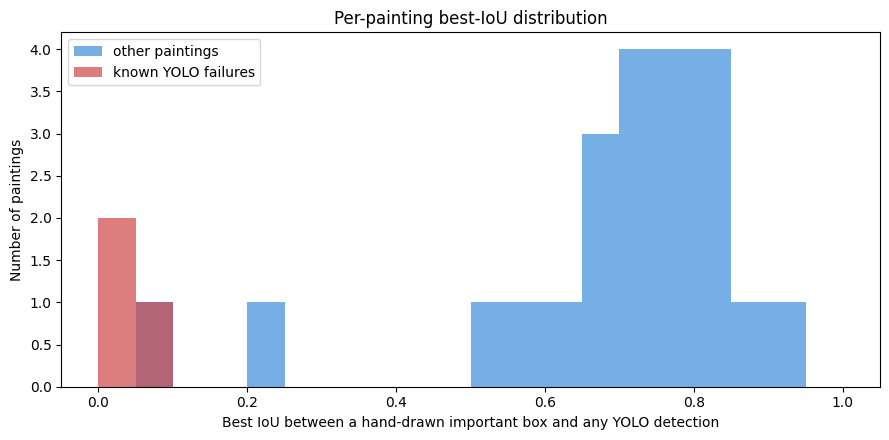

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/iou_threshold_sweep.csv
Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/iou_per_painting.csv


In [27]:
# Optional: painting_ids you independently judge to be true YOLO detection failures.
# Used only to annotate the sweep - leave empty if you don't want to pre-judge.
KNOWN_FAILURES = {"19", "24", "25"}

sweep_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

sweep_rows = []
for t in sweep_thresholds:
    passed = gate_df[gate_df["any_important_iou"] >= t]
    failed = gate_df[gate_df["any_important_iou"] <  t]

    row = {
        "iou_threshold": t,
        "n_passed":      len(passed),
        "n_failed":      len(failed),
    }
    if KNOWN_FAILURES:
        # Of the paintings the threshold rejects, how many are known failures? (true rejects)
        # Of the paintings it accepts, how many are known failures? (false accepts)
        rejected_ids = set(failed["painting_id"])
        accepted_ids = set(passed["painting_id"])
        row["known_failures_rejected"] = len(rejected_ids & KNOWN_FAILURES)
        row["known_failures_accepted"] = len(accepted_ids & KNOWN_FAILURES)
        row["good_paintings_rejected"] = len(rejected_ids - KNOWN_FAILURES)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows)
print("IoU threshold sweep:")
display(sweep_df)

# Histogram of per-painting best-IoU, split by known-failure status if provided.
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 1, 21)
if KNOWN_FAILURES:
    is_known_fail = gate_df["painting_id"].isin(KNOWN_FAILURES)
    ax.hist(gate_df.loc[~is_known_fail, "any_important_iou"], bins=bins, alpha=0.7,
            label="other paintings", color="#3b8edb")
    ax.hist(gate_df.loc[is_known_fail, "any_important_iou"], bins=bins, alpha=0.7,
            label="known YOLO failures", color="#d04646")
else:
    ax.hist(gate_df["any_important_iou"], bins=bins, alpha=0.8, color="#3b8edb")
ax.set_xlabel("Best IoU between a hand-drawn important box and any YOLO detection")
ax.set_ylabel("Number of paintings")
ax.set_title("Per-painting best-IoU distribution")
ax.legend()
plt.tight_layout()
plt.savefig(PILOT_OUTPUT_DIR / "iou_calibration_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

sweep_df.to_csv(PILOT_OUTPUT_DIR / "iou_threshold_sweep.csv", index=False)
gate_df.drop(columns=["_per_box_iou"]).to_csv(
    PILOT_OUTPUT_DIR / "iou_per_painting.csv", index=False)
print(f"Saved: {PILOT_OUTPUT_DIR / 'iou_threshold_sweep.csv'}")
print(f"Saved: {PILOT_OUTPUT_DIR / 'iou_per_painting.csv'}")

## 4.3 Apply the gate

`IOU_THRESHOLD` is the calibrated value. Paintings whose best important-box IoU meets
it pass into the rest of the pipeline; the rest are logged as detection failures and
dropped. Adjust `IOU_THRESHOLD` to whatever the sweep above supports.

In [28]:
# Calibrated IoU threshold for the validation gate. Set this from the sweep above.
IOU_THRESHOLD = 0.20

gate_df["passed_gate"] = gate_df["any_important_iou"] >= IOU_THRESHOLD

paintings_passed = sorted(gate_df.loc[gate_df["passed_gate"], "painting_id"],
                          key=int)
paintings_failed = sorted(gate_df.loc[~gate_df["passed_gate"], "painting_id"],
                          key=int)

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Passed the gate: {len(paintings_passed)} paintings  -> continue to feature extraction")
print(f"Failed the gate: {len(paintings_failed)} paintings  -> logged as detection failures, dropped")
print()
print("Passed:", paintings_passed)
print("Failed:", paintings_failed)

# Persist the detection-failure log - this is the §4.6 failure stream.
detection_failures = gate_df[~gate_df["passed_gate"]].drop(columns=["_per_box_iou"]).copy()
detection_failures.to_csv(PILOT_OUTPUT_DIR / "detection_failures.csv", index=False)
print(f"\nSaved: {PILOT_OUTPUT_DIR / 'detection_failures.csv'}")

IoU threshold: 0.2
Passed the gate: 21 paintings  -> continue to feature extraction
Failed the gate: 4 paintings  -> logged as detection failures, dropped

Passed: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '20', '21', '23']
Failed: ['19', '22', '24', '25']

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/detection_failures.csv


# 5. Batch Run — Feature Extraction

The technique stack (SAM3 masks + DIS saliency + isolation/elevation/salience features)
runs only on the paintings that passed the IoU gate. The batch helpers are unchanged
from the original pipeline; the only difference is the input list.

## 5.1 Path sanity check

In [29]:
# Verify each passing painting has an image and a SAM3 mask folder before the loop.
check_rows = []
for pid in paintings_passed:
    image_path = PLAIN_IMAGES_DIR / f"{pid}.jpg"
    mask_dir   = SAM3_ROOT / pid
    n_masks = len(list(mask_dir.glob("*.png"))) if mask_dir.exists() else 0
    check_rows.append({
        "painting_id":     pid,
        "image_exists":    image_path.exists(),
        "mask_dir_exists": mask_dir.exists(),
        "n_sam3_masks":    n_masks,
    })

path_check = pd.DataFrame(check_rows)
display(path_check)

problems = path_check[
    (~path_check["image_exists"]) |
    (~path_check["mask_dir_exists"]) |
    (path_check["n_sam3_masks"] == 0)
]
if len(problems) > 0:
    print("Problems detected - these paintings will fail in the batch loop:")
    display(problems)
else:
    print("All passing paintings have an image and at least one SAM3 mask. Good to go.")

,painting_id,image_exists,mask_dir_exists,n_sam3_masks
0,1,True,True,11
1,2,True,True,5
2,3,True,True,2
3,4,True,True,3
4,5,True,True,3
5,6,True,True,5
6,7,True,True,7
7,8,True,True,14
8,9,True,True,2
9,10,True,True,5


All passing paintings have an image and at least one SAM3 mask. Good to go.


## 5.2 Batch helpers

In [30]:
# Helper functions for the batch loop. A few notes:
#
# - load_image_rgb()           : OpenCV reads BGR; matplotlib and our masks expect RGB, so we convert.
# - load_binary_mask()         : robust to PNGs that are 0/1, 0/255, or accidentally inverted.
# - _centroid_bbox_area()      : centroid + bbox + area in ONE C-level pass via cv2.moments,
#                                instead of three separate np.where / .sum() passes per mask.
#                                For a 7494x4924 mask this is the difference between ~30ms and ~2s.
# - save_figure_id_preview()   : downscales the canvas to PREVIEW_MAX_DIM on the long side before
#                                rendering. The naive version was allocating ~1.2 GB of float64 RGBA
#                                per figure and crashing the laptop on 11-figure paintings.

PREVIEW_MAX_DIM = 1600  # long side of the preview canvas, in pixels


def load_image_rgb(path):
    """Read an image from disk and return it as an RGB numpy array."""
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not load image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def find_image_for_painting_id(image_dir, painting_id):
    """Locate the painting file whose stem matches `painting_id`."""
    image_dir = Path(image_dir)
    painting_id = str(painting_id)

    for name in (f"{painting_id}.jpg", f"jpg{painting_id}.jpg",
                 f"{painting_id}.png", f"jpg{painting_id}.png"):
        path = image_dir / name
        if path.exists():
            return path

    for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp", "*.tif", "*.tiff"):
        for path in image_dir.glob(ext):
            if path.stem.endswith(painting_id):
                return path

    return None


def find_saliency_file_for_painting(saliency_dir, painting_id):
    """Locate the DIS output for a painting, if one exists."""
    saliency_dir = Path(saliency_dir)
    painting_id = str(painting_id)

    if not saliency_dir.exists():
        return None

    possible_stems = {painting_id, f"jpg{painting_id}", f"image{painting_id}", f"img{painting_id}"}

    files = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.npy"):
        files.extend(saliency_dir.rglob(ext))

    for path in sorted(files):
        if path.stem.lower() in possible_stems:
            return path
    for path in sorted(files):
        if path.stem.lower().endswith(painting_id):
            return path
    return None


def load_binary_mask(path, target_shape):
    """Load a SAM3 mask as a boolean array, resized to (H, W) if necessary."""
    H, W = target_shape

    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not load mask: {path}")

    if mask.shape != (H, W):
        mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

    # Some PNGs come in as 0/1, others as 0/255 - threshold accordingly.
    thresh = 0 if mask.max() <= 1 else 127
    binary = mask > thresh

    # Safety: SAM3 occasionally exports an inverted mask. If the foreground
    # covers more than half the image, it's almost certainly inverted.
    if binary.mean() > 0.5:
        binary = ~binary

    return binary


def _centroid_bbox_area(mask):
    """Centroid + tight bbox + area for a binary mask, in one cv2 call."""
    mask_u8 = mask.astype(np.uint8)

    M = cv2.moments(mask_u8, binaryImage=True)
    if M["m00"] == 0:
        return (np.nan, np.nan), [np.nan, np.nan, np.nan, np.nan], 0

    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    area = int(M["m00"])

    x, y, w, h = cv2.boundingRect(mask_u8)
    bbox = [int(x), int(y), int(x + w - 1), int(y + h - 1)]
    return (float(cx), float(cy)), bbox, area


# These two are also defined in the technique cells above; we redefine them
# here so the batch path uses the fast cv2 versions.
def mask_centroid(mask):
    (cx, cy), _, _ = _centroid_bbox_area(mask)
    return cx, cy


def mask_bbox(mask):
    _, bbox, _ = _centroid_bbox_area(mask)
    return bbox


def load_figures_for_painting(mask_dir, image_shape):
    """
    Read every mask in `mask_dir`, build a `figures` list with consistent
    fig_NNN ids based on left-to-right ordering of the mask centroids.
    """
    mask_dir = Path(mask_dir)
    H, W = image_shape

    mask_files = sorted(
        list(mask_dir.glob("*.png")) +
        list(mask_dir.glob("*.jpg")) +
        list(mask_dir.glob("*.jpeg")) +
        list(mask_dir.glob("*.npy"))
    )

    figures_raw = []
    for mask_path in mask_files:
        mask = load_binary_mask(mask_path, target_shape=(H, W))
        if not np.any(mask):
            continue

        (cx, cy), bbox, area = _centroid_bbox_area(mask)
        figures_raw.append({
            "mask_file": mask_path.name,
            "mask_path": str(mask_path),
            "mask": mask,
            "bbox": bbox,
            "centroid_x": cx,
            "centroid_y": cy,
            "mask_area": area,
        })

    # Left-to-right ordering. Ties broken by y so vertically stacked figures
    # still get a deterministic order.
    figures_raw.sort(key=lambda f: (f["centroid_x"], f["centroid_y"]))

    return [
        {"figure_id": f"fig_{i:03d}", **fig}
        for i, fig in enumerate(figures_raw, start=1)
    ]


def save_figure_id_preview(image_rgb, figures, painting_id, save_path,
                           max_dim=PREVIEW_MAX_DIM):
    """
    Save a coloured-overlay PNG with each figure's automatic id printed on top.

    The image is downscaled to `max_dim` on the long side before any drawing,
    which keeps memory use in the tens of MB even for very large paintings.
    """
    H, W = image_rgb.shape[:2]
    long_side = max(H, W)

    if long_side > max_dim:
        scale = max_dim / long_side
        new_w, new_h = int(round(W * scale)), int(round(H * scale))
        small_img = cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
    else:
        scale = 1.0
        new_w, new_h = W, H
        small_img = image_rgb.copy()

    overlay_rgb = small_img.copy()

    for i, figure in enumerate(figures):
        mask = figure["mask"]

        if scale != 1.0:
            mask_small = cv2.resize(
                mask.astype(np.uint8), (new_w, new_h), interpolation=cv2.INTER_NEAREST
            ).astype(bool)
        else:
            mask_small = mask

        color = (np.array(plt.cm.tab10(i % 10)[:3]) * 255).astype(np.uint8)
        overlay_rgb[mask_small] = color

    blended = cv2.addWeighted(small_img, 0.55, overlay_rgb, 0.45, 0)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(blended)

    for figure in figures:
        cx = figure["centroid_x"] * scale
        cy = figure["centroid_y"] * scale
        ax.text(
            cx, cy, figure["figure_id"],
            color="white", fontsize=11, weight="bold",
            ha="center", va="center",
            bbox=dict(facecolor="black", alpha=0.75, pad=2),
        )

    ax.axis("off")
    ax.set_title(f"Painting {painting_id}: automatic figure IDs", fontsize=14)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    del overlay_rgb, blended, small_img
    gc.collect()


In [31]:
def process_one_pilot_painting(painting_id):
    """
    Run the whole technique stack on one painting and return:
        feature_df : a per-figure DataFrame with all candidate features merged
        status     : a small dict describing what happened (success / failure / why)
    """
    painting_id = str(painting_id)

    image_path = find_image_for_painting_id(PLAIN_IMAGES_DIR, painting_id)
    mask_dir   = SAM3_ROOT / painting_id

    if image_path is None:
        return None, {"painting_id": painting_id, "status": "failed",
                      "reason": "original image not found", "n_figures": 0}
    if not mask_dir.exists():
        return None, {"painting_id": painting_id, "status": "failed",
                      "reason": "SAM3 mask folder not found", "n_figures": 0}

    image_rgb = load_image_rgb(image_path)
    H, W = image_rgb.shape[:2]

    figures = load_figures_for_painting(mask_dir=mask_dir, image_shape=(H, W))
    if len(figures) == 0:
        return None, {"painting_id": painting_id, "status": "failed",
                      "reason": "no usable masks found", "n_figures": 0}

    preview_path = PILOT_PREVIEW_DIR / f"{painting_id}_figure_ids.png"
    save_figure_id_preview(image_rgb, figures, painting_id, preview_path)

    iso_df = compute_isolation_features(
        painting_id=painting_id, figures=figures,
        image_width=W, image_height=H,
        local_density_radii=(0.10, 0.15, 0.20),
        compute_boundary_distance=False,
    )

    elev_df = compute_elevation_features(
        painting_id=painting_id, figures=figures,
        image_width=W, image_height=H,
    )

    # Saliency is optional - some paintings don't have a DIS output yet.
    saliency_path = find_saliency_file_for_painting(DIS_DIR, painting_id)
    sal_df = None
    if saliency_path is not None:
        saliency_map = load_saliency_map(str(saliency_path), target_shape=(H, W))
        sal_df = compute_saliency_features(
            painting_id=painting_id, figures=figures,
            saliency_map=saliency_map,
            image_width=W, image_height=H,
            high_thresholds=(0.50, 0.75, 0.90),
            surrounding_dilation_px=40,
        )

    # Merge the per-family DataFrames on (painting_id, figure_id).
    dfs_to_merge = [iso_df, elev_df]
    if sal_df is not None:
        dfs_to_merge.append(sal_df)

    feature_df = reduce(
        lambda left, right: pd.merge(
            left, right,
            on=["painting_id", "figure_id"],
            how="outer",
            suffixes=("", "_duplicate"),
        ),
        dfs_to_merge,
    )

    duplicate_cols = [c for c in feature_df.columns if c.endswith("_duplicate")]
    feature_df = feature_df.drop(columns=duplicate_cols)

    # Provenance columns - useful when something looks wrong later.
    feature_df["image_path"]         = str(image_path)
    feature_df["mask_dir"]           = str(mask_dir)
    feature_df["preview_path"]       = str(preview_path)
    feature_df["saliency_path"]      = str(saliency_path) if saliency_path is not None else ""
    feature_df["image_width"]        = W
    feature_df["image_height"]       = H
    feature_df["n_figures_detected"] = len(figures)

    status = {
        "painting_id":   painting_id,
        "status":        "success",
        "reason":        "",
        "image_path":    str(image_path),
        "mask_dir":      str(mask_dir),
        "preview_path":  str(preview_path),
        "saliency_path": str(saliency_path) if saliency_path is not None else "",
        "n_figures":     len(figures),
    }
    return feature_df, status


## 5.3 Run the batch

In [32]:
# Process every painting that passed the IoU gate. Errors are caught per-painting so
# one bad mask folder doesn't kill the run; memory is freed between paintings.
all_feature_dfs = []
status_rows = []

for painting_id in paintings_passed:
    print("Processing painting:", painting_id)
    feature_df = None
    try:
        feature_df, status = process_one_pilot_painting(painting_id)
        status_rows.append(status)
        if feature_df is not None:
            feature_path = PILOT_FEATURE_DIR / f"{painting_id}_features.csv"
            feature_df.to_csv(feature_path, index=False)
            all_feature_dfs.append(feature_df)
            print(f"  success: {len(feature_df)} figures")
        else:
            print(f"  failed: {status['reason']}")
    except Exception as e:
        status_rows.append({
            "painting_id": str(painting_id), "status": "failed",
            "reason": str(e), "image_path": "", "mask_dir": str(SAM3_ROOT / str(painting_id)),
            "preview_path": "", "saliency_path": "", "n_figures": 0,
        })
        print("  error:", e)

    plt.close("all")
    if feature_df is not None:
        del feature_df
    gc.collect()

status_df = pd.DataFrame(status_rows)

if all_feature_dfs:
    all_pilot_features = pd.concat(all_feature_dfs, ignore_index=True)
else:
    all_pilot_features = pd.DataFrame()

all_pilot_features.to_csv(PILOT_OUTPUT_DIR / "all_pilot_candidate_features_unannotated.csv", index=False)
status_df.to_csv(         PILOT_OUTPUT_DIR / "pilot_processing_status.csv", index=False)

print("\nDone.")
print(f"Total feature rows: {len(all_pilot_features)}")
print(f"Paintings processed: {all_pilot_features['painting_id'].nunique() if len(all_pilot_features) else 0}")
display(status_df)

Processing painting: 1
  success: 11 figures
Processing painting: 2
  success: 5 figures
Processing painting: 3
  success: 2 figures
Processing painting: 4
  success: 3 figures
Processing painting: 5
  success: 3 figures
Processing painting: 6
  success: 5 figures
Processing painting: 7
  success: 7 figures
Processing painting: 8
  success: 14 figures
Processing painting: 9
  success: 2 figures
Processing painting: 10
  success: 5 figures
Processing painting: 11
  success: 3 figures
Processing painting: 12
  success: 4 figures
Processing painting: 13
  success: 3 figures
Processing painting: 14
  success: 2 figures
Processing painting: 15
  success: 6 figures
Processing painting: 16
  success: 5 figures
Processing painting: 17
  success: 11 figures
Processing painting: 18
  success: 3 figures
Processing painting: 20
  success: 7 figures
Processing painting: 21
  success: 7 figures
Processing painting: 23
  success: 4 figures

Done.
Total feature rows: 112
Paintings processed: 21


,painting_id,status,reason,image_path,mask_dir,preview_path,saliency_path,n_figures
0,1,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/1.png,11
1,2,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/2.png,5
2,3,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/3.png,2
3,4,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/4.png,3
4,5,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/5.png,3
5,6,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/6.png,5
6,7,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/7.png,7
7,8,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/8.png,14
8,9,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/9.png,2
9,10,success,,/home/micah/Thesis/Images/Pilot Images/Plain i...,/home/micah/Thesis/Images/Pilot Images/outputs...,/home/micah/Thesis/Images/Pilot Images/pilot_m...,/home/micah/Thesis/Images/Pilot Images/dis/10.png,5


# 6. Annotation — Match VIA Boxes to Detected Figures

After SAM3 produces figure IDs (`fig_001 … fig_NNN`), each hand-drawn important box is
matched to the detected figure it best overlaps (highest IoU against the figure's mask
bounding box). The matched figures are labelled:

- `is_important = True` — the figure matched to any hand-drawn important box

No CSV `Important_ID` column is involved; the VIA boxes are the only source of truth.
A figure-ID preview PNG was saved per painting in the batch run, so any questionable
match can be checked visually.

In [33]:
# Load the unannotated batch features back in.
ALL_FEATURES_PATH = PILOT_OUTPUT_DIR / "all_pilot_candidate_features_unannotated.csv"
df_all = pd.read_csv(ALL_FEATURES_PATH)
df_all["painting_id"] = df_all["painting_id"].astype(str)

print(f"Loaded features: {df_all.shape}  ({df_all['painting_id'].nunique()} paintings)")


def _point_in_box(px, py, box):
    """True if point (px,py) falls inside (x1,y1,x2,y2)."""
    x1, y1, x2, y2 = box
    return (x1 <= px <= x2) and (y1 <= py <= y2)


def _box_center(box):
    x1, y1, x2, y2 = box
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


# Match every VIA important box to a detected figure.
#
# A hand-drawn box is meant to *contain* the important figure, so the primary
# test is: does a detected figure's centroid fall inside the hand-drawn box?
# If several figures fall inside the same box, the one whose centroid is closest
# to the box centre wins. If none fall inside (rare - loose box, off-centre
# figure), fall back to the nearest figure centroid to the box centre.
#
# Only centroid_x / centroid_y are needed, which are always present in the
# batch feature CSV.

important_by_painting = {}   # painting_id -> set of important figure_ids
match_log_rows = []

for pid, group in df_all.groupby("painting_id"):
    vboxes = via_important_boxes.get(pid, [])
    if not vboxes:
        important_by_painting[pid] = set()
        continue

    figs = group.dropna(subset=["centroid_x", "centroid_y"])
    fig_points = [
        (row["figure_id"], float(row["centroid_x"]), float(row["centroid_y"]))
        for _, row in figs.iterrows()
    ]

    important_ids = set()
    for box_index, vbox in enumerate(vboxes):
        if not fig_points:
            break
        bcx, bcy = _box_center(vbox)

        inside = [(fid, fx, fy) for (fid, fx, fy) in fig_points
                  if _point_in_box(fx, fy, vbox)]
        candidates = inside if inside else fig_points

        # Closest centroid to the box centre wins.
        best_fid, best_fx, best_fy = min(
            candidates,
            key=lambda t: (t[1] - bcx) ** 2 + (t[2] - bcy) ** 2,
        )
        dist = float(np.hypot(best_fx - bcx, best_fy - bcy))

        important_ids.add(best_fid)

        match_log_rows.append({
            "painting_id":      pid,
            "via_box_index":    box_index,
            "matched_figure":   best_fid,
            "matched_by":       "centroid inside box" if inside else "nearest centroid (fallback)",
            "centroid_dist_px": round(dist, 1),
        })

    important_by_painting[pid] = important_ids

match_log = pd.DataFrame(match_log_rows)
print("\nVIA box -> detected figure matches:")
display(match_log)

# Flag any fallback matches - those are worth eyeballing in the preview PNGs.
fallback = match_log[match_log["matched_by"].str.startswith("nearest")]
if len(fallback) > 0:
    print(f"\n{len(fallback)} box(es) matched by fallback (no figure centroid inside the")
    print("hand-drawn box). Check the figure_id_previews PNGs for these paintings:")
    display(fallback)

# Attach the labels.
df_all["is_important"]     = df_all.apply(
    lambda r: r["figure_id"] in important_by_painting.get(str(r["painting_id"]), set()),
    axis=1,
)

# Sanity check: every painting should have at least one important figure.
sanity = (
    df_all.groupby("painting_id")
    .agg(n_figures=("figure_id", "count"),
         n_important=("is_important", "sum"))
    .reset_index()
)
print("\nSanity check (per painting):")
display(sanity)


ANNOTATED_PATH = PILOT_OUTPUT_DIR / "all_pilot_candidate_features_annotated.csv"
df_all.to_csv(ANNOTATED_PATH, index=False)
match_log.to_csv(PILOT_OUTPUT_DIR / "via_to_figure_matches.csv", index=False)
print(f"\nAnnotated features saved: {ANNOTATED_PATH}")
print(f"Marked is_important: {df_all['is_important'].sum()}")

Loaded features: (112, 77)  (21 paintings)

VIA box -> detected figure matches:


,painting_id,via_box_index,matched_figure,matched_by,centroid_dist_px
0,1,0,fig_006,centroid inside box,68.6
1,1,1,fig_007,centroid inside box,101.0
2,1,2,fig_006,nearest centroid (fallback),470.1
3,10,0,fig_002,centroid inside box,67.3
4,10,1,fig_003,centroid inside box,333.9
5,11,0,fig_002,centroid inside box,63.1
6,11,1,fig_003,centroid inside box,378.8
7,12,0,fig_004,nearest centroid (fallback),584.9
8,13,0,fig_001,centroid inside box,355.3
9,13,1,fig_001,centroid inside box,335.8



6 box(es) matched by fallback (no figure centroid inside the
hand-drawn box). Check the figure_id_previews PNGs for these paintings:


,painting_id,via_box_index,matched_figure,matched_by,centroid_dist_px
2,1,2,fig_006,nearest centroid (fallback),470.1
7,12,0,fig_004,nearest centroid (fallback),584.9
22,20,0,fig_002,nearest centroid (fallback),430.2
24,21,0,fig_006,nearest centroid (fallback),1060.9
30,4,0,fig_003,nearest centroid (fallback),1460.6
40,8,0,fig_003,nearest centroid (fallback),416.5



Sanity check (per painting):


,painting_id,n_figures,n_important
0,1,11,2
1,10,5,2
2,11,3,2
3,12,4,1
4,13,3,1
5,14,2,2
6,15,6,2
7,16,5,2
8,17,11,1
9,18,3,2



Annotated features saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/all_pilot_candidate_features_annotated.csv
Marked is_important: 37


# 7. Important-Figure Counts

How many important figures does each painting have? This tells the reader how often
`is_main` and `is_important` diverge, and it identifies paintings where every detected
figure is important — those have no comparison group and drop out of the within-painting
ranking in Section 8.

Per-painting figure counts:


,painting_id,n_figures,n_important,n_non_important,scorable
0,1,11,2,9,True
1,10,5,2,3,True
2,11,3,2,1,True
3,12,4,1,3,True
4,13,3,1,2,True
5,14,2,2,0,False
6,15,6,2,4,True
7,16,5,2,3,True
8,17,11,1,10,True
9,18,3,2,1,True



Distribution of important figures per painting:


,n_important_figures,n_paintings
0,1,7
1,2,12
2,3,2



Paintings annotated:         21
Scorable (1+ imp, 1+ other): 18
Dropped (no contrast group): 3
Mean important figures:      1.76
Median important figures:    2.0

Paintings with no comparison group:


,painting_id,n_figures,n_important,n_non_important
5,14,2,2,0
14,3,2,2,0
20,9,2,2,0


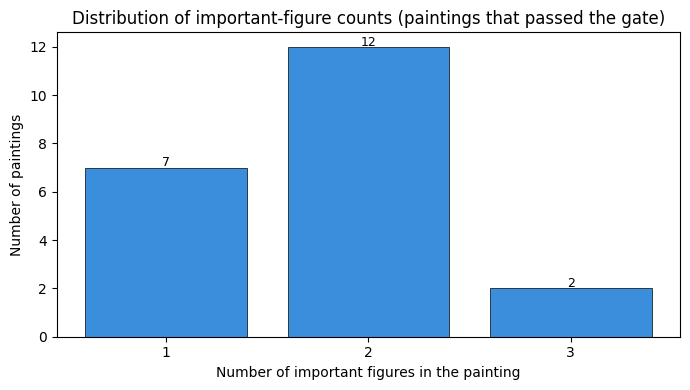


Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/important_figure_counts.csv


In [35]:
# Per-painting figure counts.
figure_counts = (
    df_all.groupby("painting_id")
    .agg(n_figures=("figure_id", "count"),
         n_important=("is_important", "sum"),)
    .reset_index()
)
figure_counts["n_non_important"] = figure_counts["n_figures"] - figure_counts["n_important"]
# Scorable = has at least one important AND one non-important figure to contrast.
figure_counts["scorable"] = (
    (figure_counts["n_important"] >= 1) & (figure_counts["n_non_important"] >= 1)
)

print("Per-painting figure counts:")
display(figure_counts)

# Distribution of important-figure counts.
dist = (
    figure_counts["n_important"].value_counts().sort_index()
    .rename_axis("n_important_figures").reset_index(name="n_paintings")
)
print("\nDistribution of important figures per painting:")
display(dist)

n_total    = len(figure_counts)
n_scorable = int(figure_counts["scorable"].sum())
print(f"\nPaintings annotated:         {n_total}")
print(f"Scorable (1+ imp, 1+ other): {n_scorable}")
print(f"Dropped (no contrast group): {n_total - n_scorable}")
print(f"Mean important figures:      {figure_counts['n_important'].mean():.2f}")
print(f"Median important figures:    {figure_counts['n_important'].median():.1f}")

if n_total - n_scorable > 0:
    print("\nPaintings with no comparison group:")
    display(figure_counts[~figure_counts["scorable"]]
            [["painting_id", "n_figures", "n_important", "n_non_important"]])

# Bar chart for Section 4.1 of the thesis.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist["n_important_figures"].astype(str), dist["n_paintings"],
       color="#3b8edb", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of important figures in the painting")
ax.set_ylabel("Number of paintings")
ax.set_title("Distribution of important-figure counts (paintings that passed the gate)")
for i, v in enumerate(dist["n_paintings"]):
    ax.text(i, v + 0.05, str(int(v)), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PILOT_OUTPUT_DIR / "important_figure_count_distribution.png",
            dpi=200, bbox_inches="tight")
plt.show()

figure_counts.to_csv(PILOT_OUTPUT_DIR / "important_figure_counts.csv", index=False)
dist.to_csv(PILOT_OUTPUT_DIR / "important_figure_count_distribution.csv", index=False)
print(f"\nSaved: {PILOT_OUTPUT_DIR / 'important_figure_counts.csv'}")

# 8. Technique Ranking

Every candidate technique — individual features *and* composites — is ranked with
standard information-retrieval metrics, in one pass, against both annotation targets.
The mean-rank tie handling inside `rank_score_feature` neutralises tie inflation, so
there is no separate strict/lenient pass.

- **Precision@1** — is the rank-1 figure important?
- **Recall@3** — of a painting's important figures, how many land in the top 3?
- **MRR** — reciprocal rank of the best-ranked important figure (primary sort key)
- **Hit@3** — is *any* important figure in the top 3?

## 8.1 Ranking metric functions

In [36]:
# Standard ranking metrics.
#
# Supervisor feedback: replace the home-grown scores (top1_rate, positive_rate,
# effect_stability) with metrics that researchers recognise. For each painting,
# every figure is scored by a feature/composite; the important figure(s) should
# rank near the top. This is a standard information-retrieval setup, so we use
# standard IR metrics:
#
#   Precision@1 - fraction of paintings where the rank-1 figure is important.
#                 (this is the old "top1_rate" under its standard name)
#   Recall@3    - of a painting's important figures, the fraction that land in
#                 the top 3. The natural partner to Precision@1, and it credits
#                 paintings with several important figures properly.
#   MRR         - Mean Reciprocal Rank: 1 / (rank of the best-ranked important
#                 figure), averaged across paintings. Overall ranking quality.
#   Hit@3       - fraction of paintings where ANY important figure is in the top 3.
#
# Ties are broken with mean ranking (tied figures share the average of the ranks
# they span), which removes the tie-inflation problem - no separate strict pass.


def _ranks_with_ties(scores):
    """Competition-style mean ranking. Highest score -> rank 1; ties share the mean rank."""
    scores = np.asarray(scores, dtype=float)
    order  = np.argsort(-scores, kind="mergesort")
    ranks  = np.empty(len(scores), dtype=float)
    i = 0
    while i < len(scores):
        j = i
        while j + 1 < len(scores) and scores[order[j + 1]] == scores[order[i]]:
            j += 1
        mean_rank = np.mean(np.arange(i + 1, j + 2))
        for k in range(i, j + 1):
            ranks[order[k]] = mean_rank
        i = j + 1
    return ranks


def rank_score_feature(
    df,
    feature_col,
    higher_is_better=True,
    painting_col="painting_id",
    important_col="is_important",
    k=3,
):
    """
    Standard IR ranking metrics for one feature.
    Evaluated within each painting, then averaged across paintings.

    Metrics returned:
      precision_at_1, precision_at_3
      recall_at_1,    recall_at_3
      mrr
      hit_at_3
    """
    p1, p3, r1, r3, mrr_vals, hit3 = [], [], [], [], [], []
    usable = 0

    for _, group in df.groupby(painting_col):
        group = group.dropna(subset=[feature_col, important_col])
        if group.empty:
            continue
        imp = group[important_col].to_numpy(dtype=bool)
        if imp.sum() == 0 or (~imp).sum() == 0:
            continue

        vals   = group[feature_col].to_numpy(dtype=float)
        scores = vals if higher_is_better else -vals
        ranks  = _ranks_with_ties(scores)
        n_imp  = int(imp.sum())

        # Precision@1 — is the unique top-ranked figure important?
        top_rank = ranks.min()
        p1.append(float(np.all(imp[ranks == top_rank]) and top_rank == 1.0))

        # Precision@3 — fraction of top-3 slots that are important
        in_top3 = ranks <= 3
        p3.append(imp[in_top3].sum() / max(in_top3.sum(), 1))

        # Recall@1 — fraction of important figures at rank 1
        r1.append(imp[ranks == 1.0].sum() / n_imp)

        # Recall@3 — fraction of important figures in top 3
        r3.append(imp[ranks <= 3].sum() / n_imp)

        # MRR — reciprocal of best rank held by an important figure
        mrr_vals.append(1.0 / ranks[imp].min())

        # Hit@3 — any important figure in top 3?
        hit3.append(float(np.any(ranks[imp] <= 3)))

        usable += 1

    if usable == 0:
        return {"feature": feature_col, "usable_paintings": 0,
                "P@1": np.nan, "P@3": np.nan,
                "R@1": np.nan, "R@3": np.nan,
                "MRR": np.nan, "Hit@3": np.nan}

    return {
        "feature":          feature_col,
        "usable_paintings": usable,
        "P@1":  float(np.mean(p1)),
        "P@3":  float(np.mean(p3)),
        "R@1":  float(np.mean(r1)),
        "R@3":  float(np.mean(r3)),
        "MRR":  float(np.mean(mrr_vals)),
        "Hit@3": float(np.mean(hit3)),
    }


def rank_score_multiple(df, candidate_directions,
                        painting_col="painting_id",
                        important_col="is_important"):
    results = []
    for feature_col, higher_is_better in candidate_directions.items():
        if feature_col not in df.columns:
            continue
        r = rank_score_feature(df, feature_col, higher_is_better,
                               painting_col, important_col)
        r["higher_is_better"] = higher_is_better
        results.append(r)
    results_df = pd.DataFrame(results)
    return results_df.sort_values(
        by=["MRR", "P@1"], ascending=False
    ).reset_index(drop=True)


print("rank_score_feature updated: nDCG removed, P@1/P@3/R@1/R@3/MRR/Hit@3 retained.")

rank_score_feature updated: nDCG removed, P@1/P@3/R@1/R@3/MRR/Hit@3 retained.


## 8.2 Build composites and run the ranking

In [37]:
# Direction of each candidate feature: True = higher value means more emphasis.
candidate_directions = {
    # isolation
    "iso_nearest_centroid_norm":    True,
    "iso_average_centroid_norm":    True,
    "iso_nearest_boundary_norm":    True,
    "iso_local_density_r10":        False,   # lower density = more isolated
    "iso_local_density_r15":        False,
    "iso_local_density_r20":        False,
    # elevation
    "elev_bbox_centroid":           True,
    "elev_mask_centroid":           True,
    "elev_bbox_top":                True,
    "elev_mask_top":                True,
    "elev_bbox_bottom":             True,
    "elev_mask_bottom":             True,
    "elev_upper_body_proxy":        True,
    # saliency
    "sal_mean":                     True,
    "sal_median":                   True,
    "sal_sum":                      True,
    "sal_share":                    True,
    "sal_max":                      True,
    "sal_p90":                      True,
    "sal_high_coverage_50":         True,
    "sal_high_coverage_75":         True,
    "sal_high_coverage_90":         True,
    "sal_contrast_to_image_mean":   True,
    "sal_contrast_to_surrounding":  True,
}
candidate_directions = {k: v for k, v in candidate_directions.items() if k in df_all.columns}


def pick_best_in_family(ranking_df, prefix):
    """Return (feature_name, higher_is_better) for the top-MRR usable feature in this family."""
    fam = ranking_df[ranking_df["feature"].str.startswith(prefix)]
    fam = fam[fam["usable_paintings"] > 0]
    if fam.empty:
        return None, True
    row = fam.iloc[0]
    return row["feature"], bool(row["higher_is_better"])


# First pass: rank the individual features, so we can choose the composite ingredients.
individual_ranking = rank_score_multiple(df_all, candidate_directions, important_col="is_important")

best_iso,  iso_higher  = pick_best_in_family(individual_ranking, "iso_")
best_elev, elev_higher = pick_best_in_family(individual_ranking, "elev_")
best_sal,  sal_higher  = pick_best_in_family(individual_ranking, "sal_")

print("Best individual feature per family (by MRR vs is_important):")
print(f"  isolation: {best_iso}   (higher_is_better={iso_higher})")
print(f"  elevation: {best_elev}  (higher_is_better={elev_higher})")
print(f"  saliency:  {best_sal}   (higher_is_better={sal_higher})")

if not (best_iso and best_elev and best_sal):
    raise ValueError("Could not pick all three families - check the individual ranking above.")

# Build the composites from those three features.
df_combo_batch = add_composite_scores(
    df_all,
    isolation_feature=best_iso,
    elevation_feature=best_elev,
    saliency_feature=best_sal,
    isolation_higher_is_better=iso_higher,
    elevation_higher_is_better=elev_higher,
    saliency_higher_is_better=sal_higher,
)

composite_directions = {
    "combo_equal_iso_elev_sal":  True,
    "combo_saliency_heavy":      True,
    "combo_spatial_heavy":       True,
    "combo_isolation_heavy":     True,
    "combo_elevation_heavy":     True,
    "combo_iso_sal":             True,
    "combo_elev_sal":            True,
    "combo_iso_elev":            True,
    "combo_minimum_score":       True,
    "combo_maximum_score":       True,
}

composite_recipe = f"iso={best_iso} | elev={best_elev} | sal={best_sal}"
print(f"\nComposite recipe: {composite_recipe}")
print(f"Built composites for {df_combo_batch['painting_id'].nunique()} paintings.")

Best individual feature per family (by MRR vs is_important):
  isolation: iso_nearest_centroid_norm   (higher_is_better=True)
  elevation: elev_bbox_top  (higher_is_better=True)
  saliency:  sal_sum   (higher_is_better=True)

Composite recipe: iso=iso_nearest_centroid_norm | elev=elev_bbox_top | sal=sal_sum
Built composites for 21 paintings.


## 8.3 Final technique ranking

One ranked table per annotation target, individual features and composites together.
`is_important` is the table the full-run decision is based on.

In [38]:
all_directions = {**candidate_directions, **composite_directions}

ranking_important = rank_score_multiple(
    df_combo_batch, all_directions, important_col="is_important"
)
ranking_important["type"] = ranking_important["feature"].apply(
    lambda f: "composite" if f.startswith("combo_") else "individual"
)

display_cols = ["feature", "type", "usable_paintings",
                "P@1", "P@3", "R@1", "R@3", "MRR", "Hit@3"]

print("=" * 80)
print("TECHNIQUE RANKING vs is_important — sorted by MRR")
print("=" * 80)
display(ranking_important[display_cols].round(3))

ranking_important.to_csv(
    PILOT_OUTPUT_DIR / "technique_ranking_is_important.csv", index=False
)
print(f"Saved: {PILOT_OUTPUT_DIR / 'technique_ranking_is_important.csv'}")

TECHNIQUE RANKING vs is_important — sorted by MRR


,feature,type,usable_paintings,P@1,P@3,R@1,R@3,MRR,Hit@3
0,combo_saliency_heavy,composite,18,0.611,0.417,0.380,0.750,0.773,0.944
1,combo_elev_sal,composite,18,0.556,0.435,0.324,0.806,0.755,0.944
2,combo_equal_iso_elev_sal,composite,18,0.556,0.444,0.352,0.833,0.750,1.000
3,combo_spatial_heavy,composite,18,0.556,0.444,0.324,0.806,0.745,0.944
4,sal_sum,individual,18,0.556,0.417,0.352,0.759,0.743,0.889
5,sal_share,individual,18,0.556,0.417,0.352,0.759,0.743,0.889
6,sal_mean,individual,18,0.556,0.380,0.324,0.676,0.718,0.833
7,sal_contrast_to_image_mean,individual,18,0.556,0.380,0.324,0.676,0.718,0.833
8,sal_high_coverage_50,individual,18,0.556,0.352,0.324,0.602,0.715,0.778
9,combo_elevation_heavy,composite,18,0.500,0.426,0.324,0.778,0.713,0.889


Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/technique_ranking_is_important.csv


# 9. Conclusion — Techniques Locked In for the Full Run

The pilot's job was to choose the techniques and validate the IoU gate, not to answer
the research question. This section records the locked-in choices and their pilot
ranking-metric scores. These are fixed *before* the full run so no metric is selected
retrospectively on the 500–1000 painting dataset.

In [39]:
PRIMARY_TECHNIQUE   = "combo_saliency_heavy"
SECONDARY_TECHNIQUE = "sal_high_coverage_50"

COMPOSITE_RECIPE = {
    "isolation":  best_iso,
    "elevation":  best_elev,
    "saliency":   best_sal,
    "weights":    "0.50 saliency + 0.25 isolation + 0.25 elevation",
    "directions": {
        "isolation_higher_is_better": iso_higher,
        "elevation_higher_is_better": elev_higher,
        "saliency_higher_is_better":  sal_higher,
    },
}


def lookup(ranking_df, feature, col):
    """Pull a value from a ranking DataFrame, or NaN if the feature is not present."""
    indexed = ranking_df.set_index("feature")
    return indexed.loc[feature, col] if feature in indexed.index else np.nan


summary = pd.DataFrame([
    {
        "role":      "primary",
        "technique": PRIMARY_TECHNIQUE,
        "type":      "composite",
        "P@1":   lookup(ranking_important, PRIMARY_TECHNIQUE,   "P@1"),
        "P@3":   lookup(ranking_important, PRIMARY_TECHNIQUE,   "P@3"),
        "R@1":   lookup(ranking_important, PRIMARY_TECHNIQUE,   "R@1"),
        "R@3":   lookup(ranking_important, PRIMARY_TECHNIQUE,   "R@3"),
        "MRR":   lookup(ranking_important, PRIMARY_TECHNIQUE,   "MRR"),
        "Hit@3": lookup(ranking_important, PRIMARY_TECHNIQUE,   "Hit@3"),
    },
    {
        "role":      "secondary",
        "technique": SECONDARY_TECHNIQUE,
        "type":      "individual",
        "P@1":   lookup(ranking_important, SECONDARY_TECHNIQUE, "P@1"),
        "P@3":   lookup(ranking_important, SECONDARY_TECHNIQUE, "P@3"),
        "R@1":   lookup(ranking_important, SECONDARY_TECHNIQUE, "R@1"),
        "R@3":   lookup(ranking_important, SECONDARY_TECHNIQUE, "R@3"),
        "MRR":   lookup(ranking_important, SECONDARY_TECHNIQUE, "MRR"),
        "Hit@3": lookup(ranking_important, SECONDARY_TECHNIQUE, "Hit@3"),
    },
])

print("=" * 70)
print("PILOT CONCLUSION")
print("=" * 70)
print(f"IoU gate threshold:        {IOU_THRESHOLD}")
print(f"Paintings passed the gate: {len(paintings_passed)}")
print(f"Paintings failed the gate: {len(paintings_failed)}")
print(f"Figures evaluated:         {len(df_all)}")
print()
print("Composite recipe (used to build combo_saliency_heavy):")
for k, v in COMPOSITE_RECIPE.items():
    print(f"  {k}: {v}")
print()
print("Locked-in techniques, scored against is_important:")
display(summary.round(3))

summary.to_csv(PILOT_OUTPUT_DIR / "pilot_conclusion.csv", index=False)
with open(PILOT_OUTPUT_DIR / "composite_recipe.json", "w") as f:
    json.dump(COMPOSITE_RECIPE, f, indent=2, default=str)
print(f"\nSaved: {PILOT_OUTPUT_DIR / 'pilot_conclusion.csv'}")
print(f"Saved: {PILOT_OUTPUT_DIR / 'composite_recipe.json'}")


PILOT CONCLUSION
IoU gate threshold:        0.2
Paintings passed the gate: 21
Paintings failed the gate: 4
Figures evaluated:         112

Composite recipe (used to build combo_saliency_heavy):
  isolation: iso_nearest_centroid_norm
  elevation: elev_bbox_top
  saliency: sal_sum
  weights: 0.50 saliency + 0.25 isolation + 0.25 elevation
  directions: {'isolation_higher_is_better': True, 'elevation_higher_is_better': True, 'saliency_higher_is_better': True}

Locked-in techniques, scored against is_important:


,role,technique,type,P@1,P@3,R@1,R@3,MRR,Hit@3
0,primary,combo_saliency_heavy,composite,0.611,0.417,0.380,0.750,0.773,0.944
1,secondary,sal_high_coverage_50,individual,0.556,0.352,0.324,0.602,0.715,0.778



Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/pilot_conclusion.csv
Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/composite_recipe.json


## 8.4 Ablation — Marginal Contribution of Each Cue

Tests all six cue combinations to show the marginal contribution of each cue.
Directly answers the three sub-questions from Section 1 individually.

ABLATION — marginal contribution of each cue combination


,Technique,usable_paintings,P@1,P@3,R@1,R@3,MRR,Hit@3
0,Salience only,18,0.556,0.417,0.352,0.759,0.743,0.889
1,Isolation only,18,0.333,0.472,0.222,0.778,0.599,0.944
2,Elevation only,18,0.444,0.370,0.241,0.611,0.635,0.778
3,Salience + Isolation,18,0.444,0.370,0.296,0.704,0.705,0.889
4,Salience + Elevation,18,0.556,0.435,0.324,0.806,0.755,0.944
5,Isolation + Elevation,18,0.333,0.380,0.222,0.639,0.607,0.833
6,Full composite (S+I+E),18,0.611,0.417,0.380,0.750,0.773,0.944


Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/ablation_table.csv


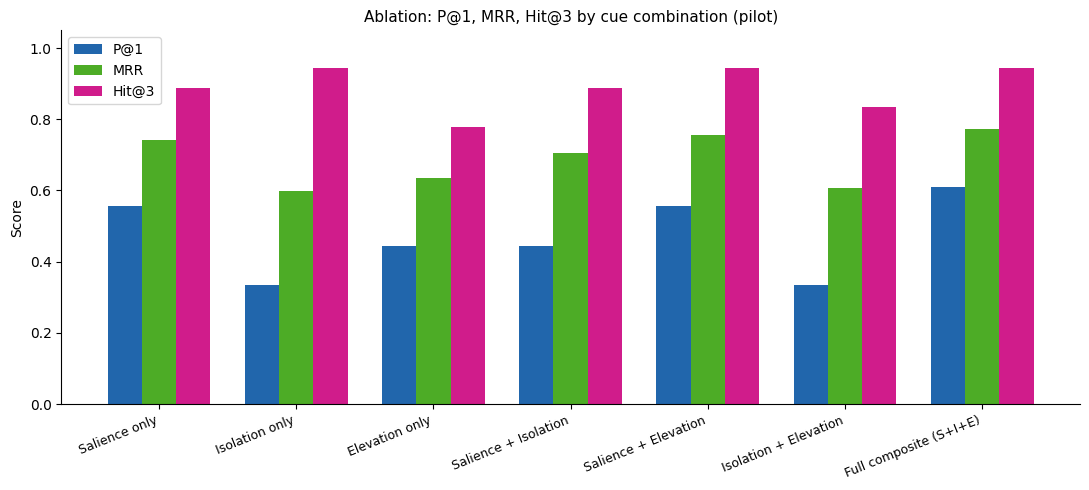

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/ablation_bar_chart.png


In [40]:
# ── ABLATION TABLE ───────────────────────────────────────────────────────────
# All 6 cue combinations. Composites iso_sal, elev_sal, iso_elev are already
# built by add_composite_scores() in Cell 41.
import matplotlib.ticker as mticker

ablation_specs = [
    (best_sal,               "Salience only"),
    (best_iso,               "Isolation only"),
    (best_elev,              "Elevation only"),
    ("combo_iso_sal",        "Salience + Isolation"),
    ("combo_elev_sal",       "Salience + Elevation"),
    ("combo_iso_elev",       "Isolation + Elevation"),
    ("combo_saliency_heavy", "Full composite (S+I+E)"),
]

abl_rows = []
for col, label in ablation_specs:
    if col not in df_combo_batch.columns:
        print(f"Skipping {col} — not found in df_combo_batch")
        continue
    r = rank_score_feature(df_combo_batch, col, important_col="is_important")
    r["Technique"] = label
    abl_rows.append(r)

abl_df = pd.DataFrame(abl_rows)[
    ["Technique", "usable_paintings", "P@1", "P@3", "R@1", "R@3", "MRR", "Hit@3"]
]
print("=" * 70)
print("ABLATION — marginal contribution of each cue combination")
print("=" * 70)
display(abl_df.round(3))
abl_df.to_csv(PILOT_OUTPUT_DIR / "ablation_table.csv", index=False)
print(f"Saved: {PILOT_OUTPUT_DIR / 'ablation_table.csv'}")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(abl_df))
width = 0.25
ax.bar(x - width, abl_df["P@1"].values,   width, label="P@1",   color="#2166ac")
ax.bar(x,          abl_df["MRR"].values,   width, label="MRR",   color="#4dac26")
ax.bar(x + width,  abl_df["Hit@3"].values, width, label="Hit@3", color="#d01c8b")
ax.set_xticks(x)
ax.set_xticklabels(abl_df["Technique"].values, rotation=22, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Ablation: P@1, MRR, Hit@3 by cue combination (pilot)", fontsize=11)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
abl_plot = PILOT_OUTPUT_DIR / "ablation_bar_chart.png"
plt.savefig(abl_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {abl_plot}")


## 8.5 Bootstrap Confidence Intervals

95% bootstrap CIs for P@1, MRR, Hit@3. Non-overlapping CIs between composite
and salience baseline confirm the composite reliably outperforms.

Computing bootstrap CIs (Monte Carlo random baseline ~20s)...

BOOTSTRAP 95% CIs — pilot


,Technique,n,P@1,P@1 CI,MRR,MRR CI,Hit@3,Hit@3 CI
0,Full composite,18,0.611,"[0.389, 0.833]",0.773,"[0.630, 0.903]",0.944,"[0.833, 1.000]"
1,Salience baseline,18,0.556,"[0.333, 0.778]",0.715,"[0.560, 0.861]",0.778,"[0.556, 0.944]"
2,Random baseline,18,0.367,"[0.280, 0.459]",0.587,"[0.501, 0.670]",0.776,"[0.647, 0.892]"


Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/bootstrap_ci.csv


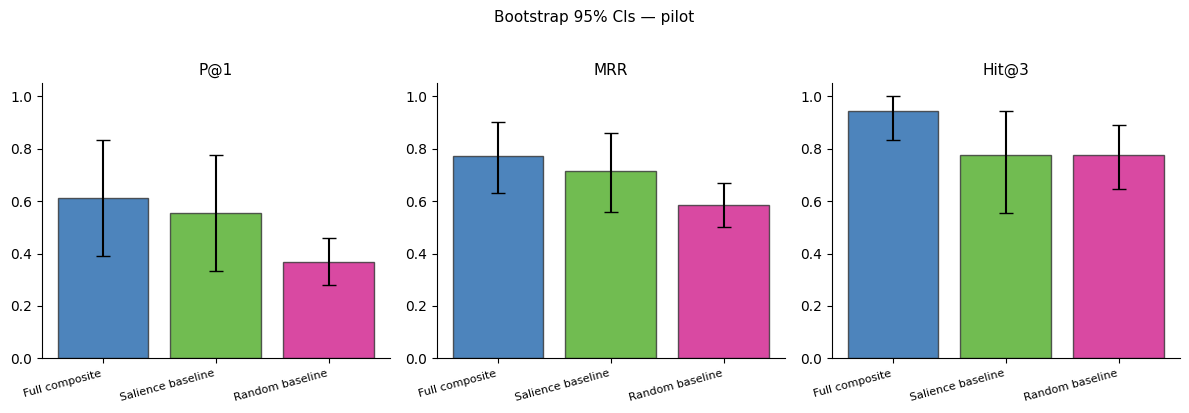

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/bootstrap_ci_plot.png


In [41]:
# ── BOOTSTRAP CONFIDENCE INTERVALS ──────────────────────────────────────────

def _per_painting_vectors(df, feature_col, important_col="is_important"):
    p1_v, mrr_v, h3_v = [], [], []
    for _, g in df.groupby("painting_id"):
        g = g.dropna(subset=[feature_col, important_col])
        if g.empty:
            continue
        imp = g[important_col].to_numpy(dtype=bool)
        if imp.sum() == 0 or (~imp).sum() == 0:
            continue
        vals  = g[feature_col].to_numpy(dtype=float)
        ranks = _ranks_with_ties(vals)
        p1_v.append(float(imp[ranks <= 1].sum()))
        mrr_v.append(1.0 / ranks[imp].min())
        h3_v.append(float(np.any(ranks[imp] <= 3)))
    return np.array(p1_v), np.array(mrr_v), np.array(h3_v)


def _random_vectors(df, important_col="is_important", n_sims=1000, seed=42):
    rng = np.random.default_rng(seed)
    p1_v, mrr_v, h3_v = [], [], []
    for _, g in df.groupby("painting_id"):
        imp = g[important_col].to_numpy(dtype=bool)
        n, n_imp = len(imp), int(imp.sum())
        if n_imp == 0 or n_imp == n:
            continue
        sims = []
        for _ in range(n_sims):
            perm  = rng.permutation(n)
            ranks = np.argsort(perm) + 1
            sims.append([imp[ranks <= 1].sum(), 1.0 / ranks[imp].min(),
                         float(np.any(ranks[imp] <= 3))])
        sims = np.array(sims)
        p1_v.append(sims[:, 0].mean())
        mrr_v.append(sims[:, 1].mean())
        h3_v.append(sims[:, 2].mean())
    return np.array(p1_v), np.array(mrr_v), np.array(h3_v)


def bootstrap_ci(values, n_boot=5000, seed=42):
    rng  = np.random.default_rng(seed)
    boot = np.array([rng.choice(values, size=len(values), replace=True).mean()
                     for _ in range(n_boot)])
    return values.mean(), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


print("Computing bootstrap CIs (Monte Carlo random baseline ~20s)...")
specs = [
    ("Full composite",    *_per_painting_vectors(df_combo_batch, "combo_saliency_heavy")),
    ("Salience baseline", *_per_painting_vectors(df_combo_batch, "sal_high_coverage_50")),
    ("Random baseline",   *_random_vectors(df_combo_batch)),
]
ci_rows = []
for label, p1_v, mrr_v, h3_v in specs:
    row = {"Technique": label, "n": len(p1_v)}
    for metric, vals in [("P@1", p1_v), ("MRR", mrr_v), ("Hit@3", h3_v)]:
        mean, lo, hi = bootstrap_ci(vals)
        row[metric]         = round(mean, 3)
        row[f"{metric} CI"] = f"[{lo:.3f}, {hi:.3f}]"
    ci_rows.append(row)
ci_df = pd.DataFrame(ci_rows)
print("\n" + "=" * 65)
print("BOOTSTRAP 95% CIs — pilot")
print("=" * 65)
display(ci_df)
ci_df.to_csv(PILOT_OUTPUT_DIR / "bootstrap_ci.csv", index=False)
print(f"Saved: {PILOT_OUTPUT_DIR / 'bootstrap_ci.csv'}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
colors = ["#2166ac", "#4dac26", "#d01c8b"]
for ax, metric in zip(axes, ["P@1", "MRR", "Hit@3"]):
    means = ci_df[metric].values
    lows  = ci_df[f"{metric} CI"].apply(lambda s: float(s.strip("[]").split(",")[0])).values
    highs = ci_df[f"{metric} CI"].apply(lambda s: float(s.strip("[]").split(",")[1])).values
    x = np.arange(len(ci_df))
    ax.bar(x, means, color=colors, alpha=0.8, edgecolor="#333", zorder=2)
    ax.errorbar(x, means, yerr=[means - lows, highs - means],
                fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(ci_df["Technique"].values, rotation=15, ha="right", fontsize=8)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Bootstrap 95% CIs — pilot", fontsize=11, y=1.02)
plt.tight_layout()
ci_plot = PILOT_OUTPUT_DIR / "bootstrap_ci_plot.png"
plt.savefig(ci_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {ci_plot}")


## 8.6 Feature Score Distributions

Violin plots: distribution of each primary feature for important vs non-important figures across all scorable paintings.

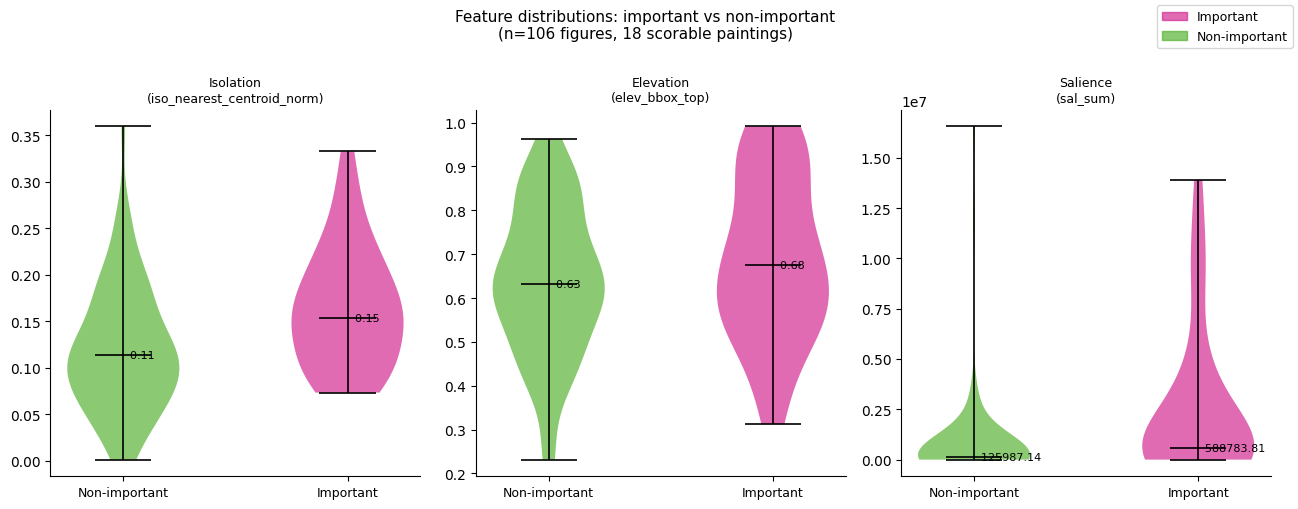

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/feature_distributions.png


In [42]:
# ── FEATURE SCORE DISTRIBUTIONS ─────────────────────────────────────────────
import matplotlib.patches as mpatches

PRIMARY_FEATURES = {
    best_iso:  f"Isolation\n({best_iso})",
    best_elev: f"Elevation\n({best_elev})",
    best_sal:  f"Salience\n({best_sal})",
}
scorable_pids = [
    pid for pid, g in df_combo_batch.groupby("painting_id")
    if g["is_important"].sum() > 0 and (~g["is_important"]).sum() > 0
]
df_plot = df_combo_batch[df_combo_batch["painting_id"].isin(scorable_pids)].copy()

COLORS = {True: "#d01c8b", False: "#4dac26"}
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (feat, label) in zip(axes, PRIMARY_FEATURES.items()):
    if feat not in df_plot.columns:
        ax.set_title(f"{label}\n(not found)")
        continue
    data_imp    = df_plot.loc[df_plot["is_important"] == True,  feat].dropna().values
    data_notimp = df_plot.loc[df_plot["is_important"] == False, feat].dropna().values
    parts = ax.violinplot([data_notimp, data_imp], positions=[1, 2],
                          showmedians=True, showextrema=True)
    for body, color in zip(parts["bodies"], [COLORS[False], COLORS[True]]):
        body.set_facecolor(color)
        body.set_alpha(0.65)
    for key in ["cmedians", "cbars", "cmins", "cmaxes"]:
        if key in parts:
            parts[key].set_color("black")
            parts[key].set_linewidth(1.2)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-important", "Important"], fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    for pos, data in [(1, data_notimp), (2, data_imp)]:
        med = np.median(data)
        ax.text(pos, med, f"  {med:.2f}", va="center", fontsize=8)

imp_patch    = mpatches.Patch(color=COLORS[True],  alpha=0.65, label="Important")
notimp_patch = mpatches.Patch(color=COLORS[False], alpha=0.65, label="Non-important")
fig.legend(handles=[imp_patch, notimp_patch], loc="upper right", fontsize=9)
fig.suptitle(
    f"Feature distributions: important vs non-important\n"
    f"(n={len(df_plot)} figures, {len(scorable_pids)} scorable paintings)",
    fontsize=11, y=1.01
)
plt.tight_layout()
dist_path = PILOT_OUTPUT_DIR / "feature_distributions.png"
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {dist_path}")


## 8.7 Cue Correlation Matrix

Spearman rank correlations between the three primary features. Low correlations justify combining them into a composite.

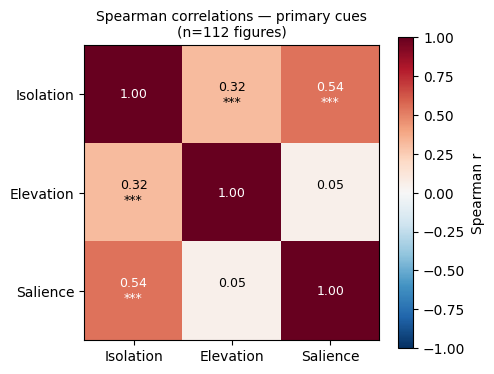

Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/cue_correlation_matrix.png
           Isolation  Elevation  Salience
Isolation      1.000      0.319     0.541
Elevation      0.319      1.000     0.053
Salience       0.541      0.053     1.000


In [43]:
# ── CUE CORRELATION MATRIX ───────────────────────────────────────────────────
from scipy.stats import spearmanr

feat_labels = {best_iso: "Isolation", best_elev: "Elevation", best_sal: "Salience"}
feats  = [f for f in feat_labels if f in df_combo_batch.columns]
labels = [feat_labels[f] for f in feats]
df_corr = df_combo_batch[feats].dropna()
n_obs   = len(df_corr)

corr_matrix = np.eye(len(feats))
pval_matrix = np.zeros((len(feats), len(feats)))
for i in range(len(feats)):
    for j in range(len(feats)):
        if i != j:
            r, p = spearmanr(df_corr[feats[i]], df_corr[feats[j]])
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_xticks(range(len(feats)))
ax.set_yticks(range(len(feats)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
for i in range(len(feats)):
    for j in range(len(feats)):
        val  = corr_matrix[i, j]
        pval = pval_matrix[i, j]
        star = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        txt  = f"{val:.2f}\n{star}" if i != j else "1.00"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.5 else "black")
ax.set_title(f"Spearman correlations — primary cues\n(n={n_obs} figures)", fontsize=10)
plt.tight_layout()
corr_path = PILOT_OUTPUT_DIR / "cue_correlation_matrix.png"
plt.savefig(corr_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {corr_path}")
print(pd.DataFrame(corr_matrix.round(3), index=labels, columns=labels))


# Appendix A — Feature Catalogue

The complete set of candidate figure-level features. `higher_is_better` indicates
whether a higher value was expected to correspond to greater visual emphasis.

In [ ]:
feature_catalogue = pd.DataFrame([
    ("Isolation", "iso_nearest_centroid_norm",   "Distance to the nearest other figure centroid, normalised by the image diagonal.", True),
    ("Isolation", "iso_average_centroid_norm",   "Mean centroid distance to all other detected figures, normalised by the image diagonal.", True),
    ("Isolation", "iso_local_density_r10",       "Number of other figure centroids within 10% of the image diagonal.", False),
    ("Isolation", "iso_local_density_r15",       "Number of other figure centroids within 15% of the image diagonal.", False),
    ("Isolation", "iso_local_density_r20",       "Number of other figure centroids within 20% of the image diagonal.", False),
    ("Isolation", "iso_nearest_boundary_norm",   "Shortest mask-to-mask distance to the nearest neighbouring figure, normalised by the image diagonal.", True),
    ("Salience",  "sal_mean",                    "Mean DIS saliency value inside the figure region.", True),
    ("Salience",  "sal_median",                  "Median DIS saliency value inside the figure region.", True),
    ("Salience",  "sal_max",                     "Maximum DIS saliency value inside the figure region.", True),
    ("Salience",  "sal_p90",                     "90th percentile DIS saliency value inside the figure region.", True),
    ("Salience",  "sal_sum",                     "Total DIS saliency contained within the figure region.", True),
    ("Salience",  "sal_share",                   "Figure saliency as a proportion of total painting saliency.", True),
    ("Salience",  "sal_high_coverage_50",        "Proportion of the figure region with saliency above 0.50.", True),
    ("Salience",  "sal_high_coverage_75",        "Proportion of the figure region with saliency above 0.75.", True),
    ("Salience",  "sal_high_coverage_90",        "Proportion of the figure region with saliency above 0.90.", True),
    ("Salience",  "sal_contrast_to_image_mean",  "Mean figure saliency divided by the mean saliency of the full image.", True),
    ("Salience",  "sal_contrast_to_surrounding", "Mean figure saliency divided by the mean saliency of the local surrounding region.", True),
    ("Elevation", "elev_bbox_centroid",          "Elevation of the bounding-box centroid, computed as 1 - y/H.", True),
    ("Elevation", "elev_mask_centroid",          "Elevation of the mask centroid, computed as 1 - y/H.", True),
    ("Elevation", "elev_bbox_top",               "Elevation of the top edge of the bounding box.", True),
    ("Elevation", "elev_mask_top",               "Elevation of the topmost point of the figure mask.", True),
    ("Elevation", "elev_bbox_bottom",            "Elevation of the bottom edge of the bounding box.", True),
    ("Elevation", "elev_mask_bottom",            "Elevation of the bottommost point of the figure mask.", True),
    ("Elevation", "elev_upper_body_proxy",       "Mean elevation of the upper 35% of the figure mask.", True),
], columns=["family", "feature", "definition", "higher_is_better"])

display(feature_catalogue)
feature_catalogue.to_csv(PILOT_OUTPUT_DIR / "feature_catalogue.csv", index=False)
print(f"Saved: {PILOT_OUTPUT_DIR / 'feature_catalogue.csv'}")

,family,feature,definition,higher_is_better
0,Isolation,iso_nearest_centroid_norm,"Distance to the nearest other figure centroid,...",True
1,Isolation,iso_average_centroid_norm,Mean centroid distance to all other detected f...,True
2,Isolation,iso_local_density_r10,Number of other figure centroids within 10% of...,False
3,Isolation,iso_local_density_r15,Number of other figure centroids within 15% of...,False
4,Isolation,iso_local_density_r20,Number of other figure centroids within 20% of...,False
5,Isolation,iso_nearest_boundary_norm,Shortest mask-to-mask distance to the nearest ...,True
6,Salience,sal_mean,Mean DIS saliency value inside the figure region.,True
7,Salience,sal_median,Median DIS saliency value inside the figure re...,True
8,Salience,sal_max,Maximum DIS saliency value inside the figure r...,True
9,Salience,sal_p90,90th percentile DIS saliency value inside the ...,True


Saved: /home/micah/Thesis/Images/Pilot Images/pilot_method_selection_outputs/feature_catalogue.csv
